# Analyzing residential property pricing trends in Bengaluru using Python and exploratory data analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv(r"C:\Users\admin\Downloads/bengaluru_house_prices.csv", 
                       on_bad_lines = "skip",
                       low_memory=False)

In [7]:
df.shape


(13320, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


__Check for missing Values__

In [8]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [11]:
df.drop('society', axis=1, inplace=True)

In [12]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath',
       'balcony', 'price'],
      dtype='object')

In [13]:
df.dropna(subset=['location', 'size'], inplace=True)

In [14]:
df['bath'].fillna(df['bath'].median(), inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_14544\3321556508.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bath'].fillna(df['bath'].median(), inplace=True)


In [15]:
df['balcony'].fillna(df['balcony'].median(), inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_14544\2345094989.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['balcony'].fillna(df['balcony'].median(), inplace=True)


In [16]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [17]:
df['size']

0            2 BHK
1        4 Bedroom
2            3 BHK
3            3 BHK
4            2 BHK
           ...    
13315    5 Bedroom
13316        4 BHK
13317        2 BHK
13318        4 BHK
13319        1 BHK
Name: size, Length: 13303, dtype: object

__Extracting digits from size columns to get BHK value__

In [18]:
df['bhk'] = df['size'].str.extract('(\d+)').astype(int)

In [20]:
df.drop('size', axis=1, inplace=True)

In [21]:
df.columns

Index(['area_type', 'availability', 'location', 'total_sqft', 'bath',
       'balcony', 'price', 'bhk'],
      dtype='object')

__cleaning data__

In [22]:
df['total_sqft'].sample(30)

6112     1240
6254     1314
6442     1056
12857    1335
8247     1320
8613      900
437      1630
12994    1565
5808     1210
11663    1075
7814     1410
11919    1400
12341    2257
4564     1500
11851     933
5989     1200
6114     1019
442      1400
10504     705
2729     1050
3990     1329
5059      660
9580     1856
12719     985
3774     1106
13190    1330
4952     1847
411      1185
12943     890
7365      900
Name: total_sqft, dtype: object

In [ ]:
df[~df['total_sqft'].str.replace('.', '', regex=False).str.isnumeric()]['total_sqft'].unique()

In [55]:
def convert_sqft_to_num(x):
    tokens = str(x).split('-')

    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2

    try:
        return float(x)
    except:
        return None

In [25]:
df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

In [28]:
df.dropna(subset=['total_sqft'], inplace=True)

In [34]:
df['total_sqft'].dtype


dtype('float64')

In [33]:
df.shape

(13257, 8)

__Create a new column calculating the price per sqft__

In [35]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

__detecting and treating outliers__

In [36]:
df['price_per_sqft'].describe()

count    1.325700e+04
mean     7.912825e+03
std      1.064976e+05
min      2.678298e+02
25%      4.271186e+03
50%      5.438596e+03
75%      7.313318e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [37]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price_per_sqft'] >= lower) & (df['price_per_sqft'] <= upper)]

In [38]:
df['price_per_sqft'].describe()

count    11990.000000
mean      5577.615880
std       1956.761359
min        267.829813
25%       4166.666667
50%       5189.189189
75%       6606.482618
max      11875.000000
Name: price_per_sqft, dtype: float64

## Price Distribution

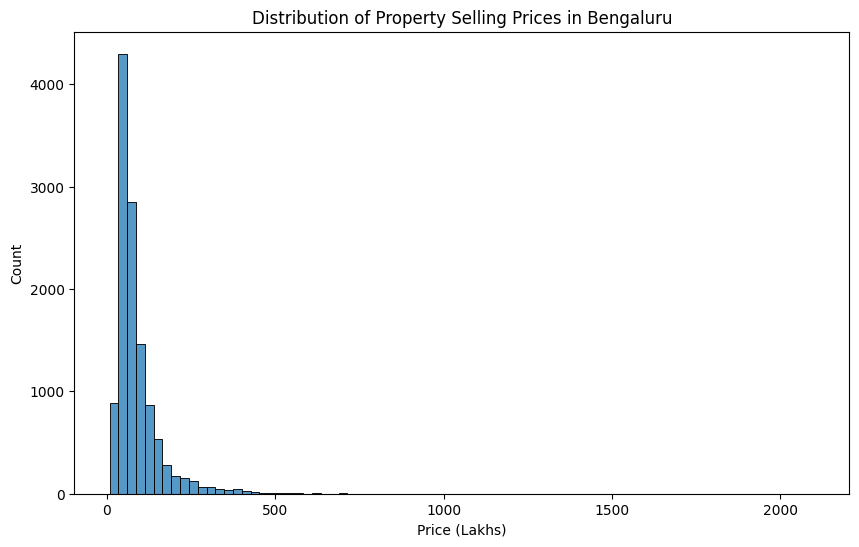

In [43]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=80)
plt.title('Distribution of Property Selling Prices in Bengaluru')
plt.xlabel('Price (Lakhs)')
plt.show()

__The Bengaluru housing market is heavily concentrated in mid-range properties, with a relatively small number of premium properties creating a long right-tail distribution.__

## BHK vs Price

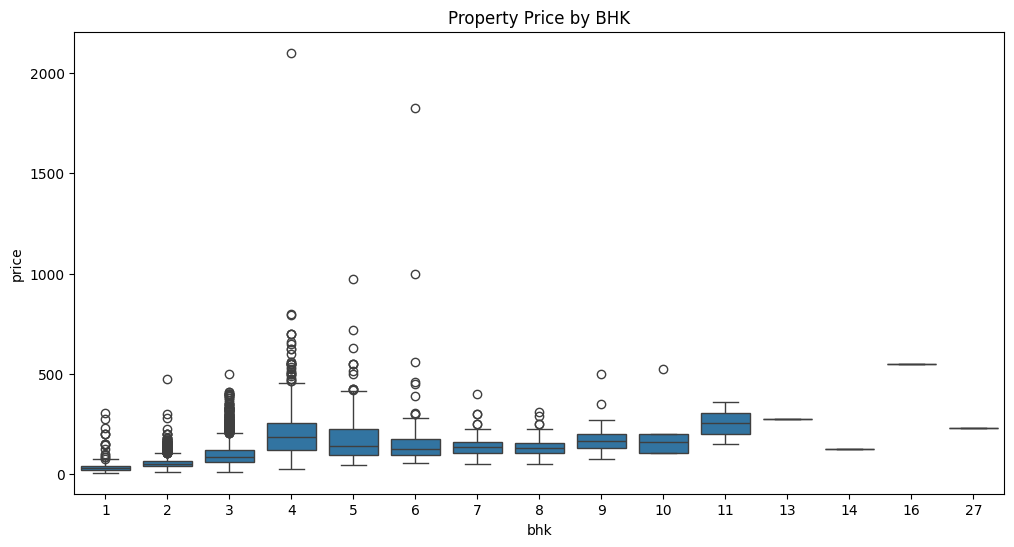

In [44]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='bhk', y='price')
plt.title('Property Price by BHK')
plt.show()

__Property prices generally increase with the number of bedrooms, but the wide price variation within each BHK category suggests that location and property size significantly influence pricing beyond just room count.__

## Total Sqft vs Price

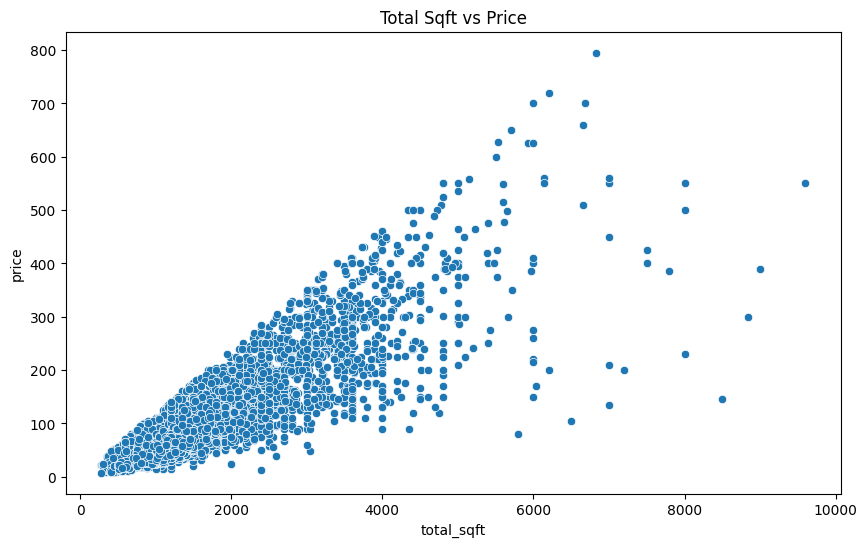

In [53]:
plot_df = df[df['total_sqft'] < 10000]
plt.figure(figsize=(10,6))
sns.scatterplot(data=plot_df, x='total_sqft', y='price')
plt.title('Total Sqft vs Price')
plt.show()

__Although larger properties generally command higher prices, significant variation exists among similarly sized homes, indicating that location and other qualitative factors strongly influence pricing.__

## Top Premium Locations

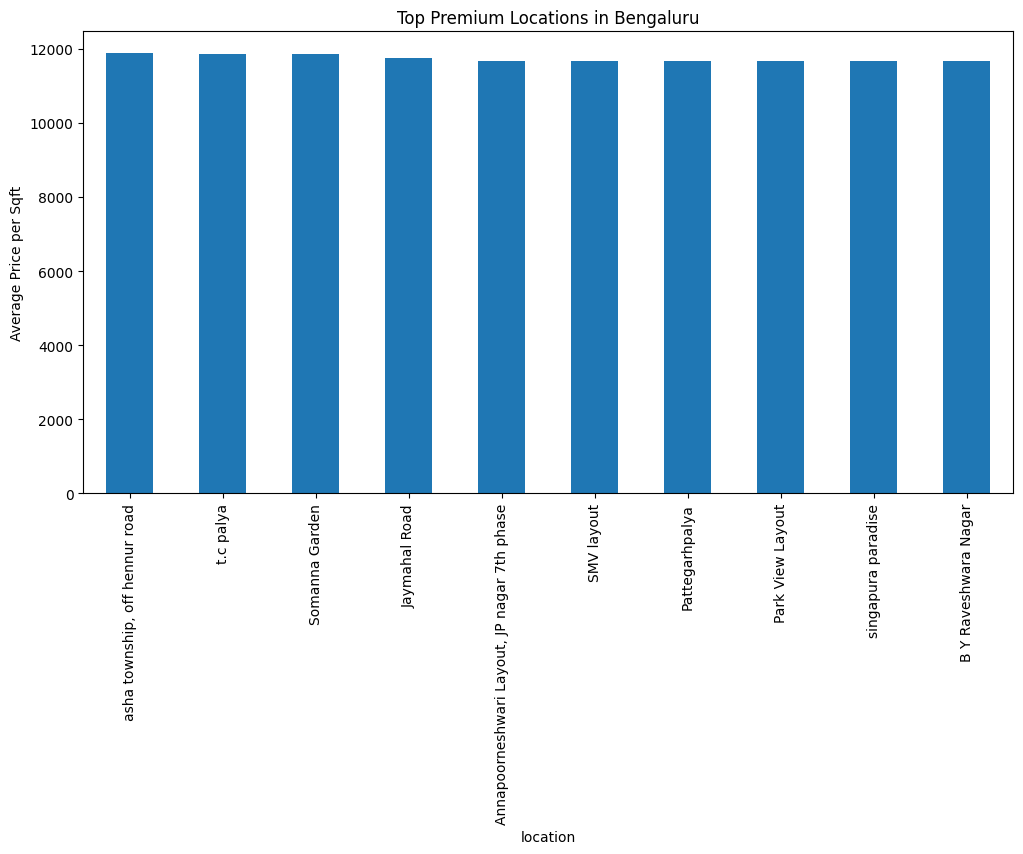

In [48]:
top_expensive = df.groupby('location')['price_per_sqft'].mean().sort_values(ascending=False).head(10)

top_expensive.plot(kind='bar', figsize=(12,6))
plt.title('Top Premium Locations in Bengaluru')
plt.ylabel('Average Price per Sqft')
plt.show()

## Best Value Locations 

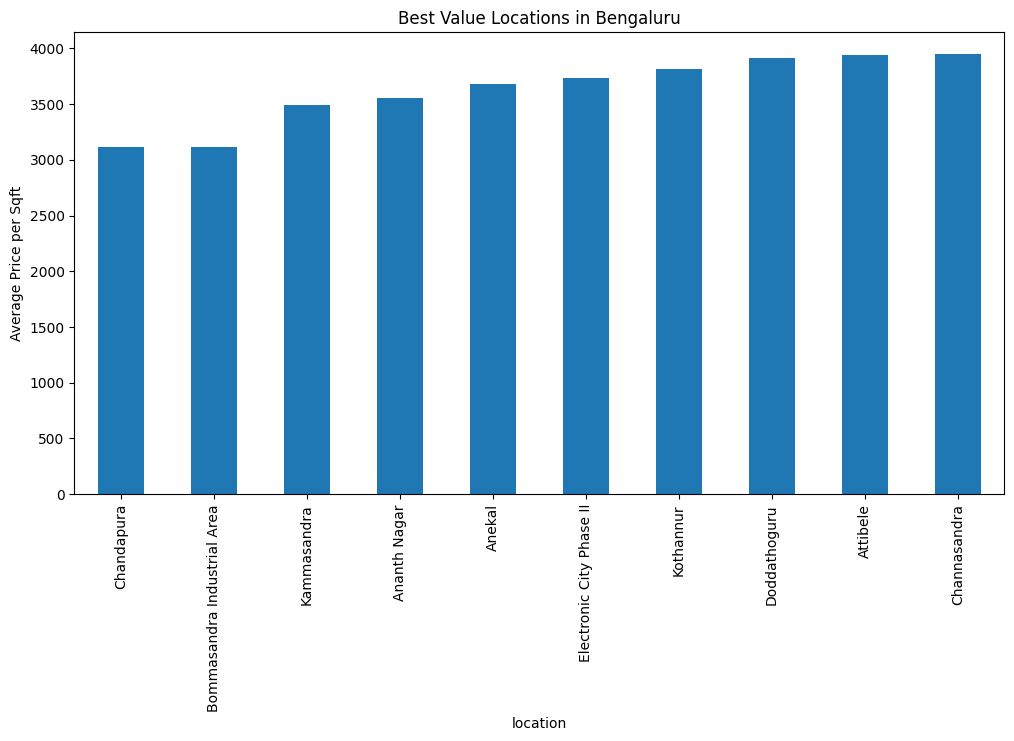

In [49]:
location_counts = df['location'].value_counts()

valid_locations = location_counts[location_counts >= 20].index

best_value = df[df['location'].isin(valid_locations)] \
    .groupby('location')['price_per_sqft'] \
    .mean() \
    .sort_values() \
    .head(10)

best_value.plot(kind='bar', figsize=(12,6))
plt.title('Best Value Locations in Bengaluru')
plt.ylabel('Average Price per Sqft')
plt.show()

__Locations such as Chandapura and Bommasandra Industrial Area emerged as comparatively affordable regions based on average price per square foot, making them attractive for cost-conscious buyers.__

## Correlation Heatmap

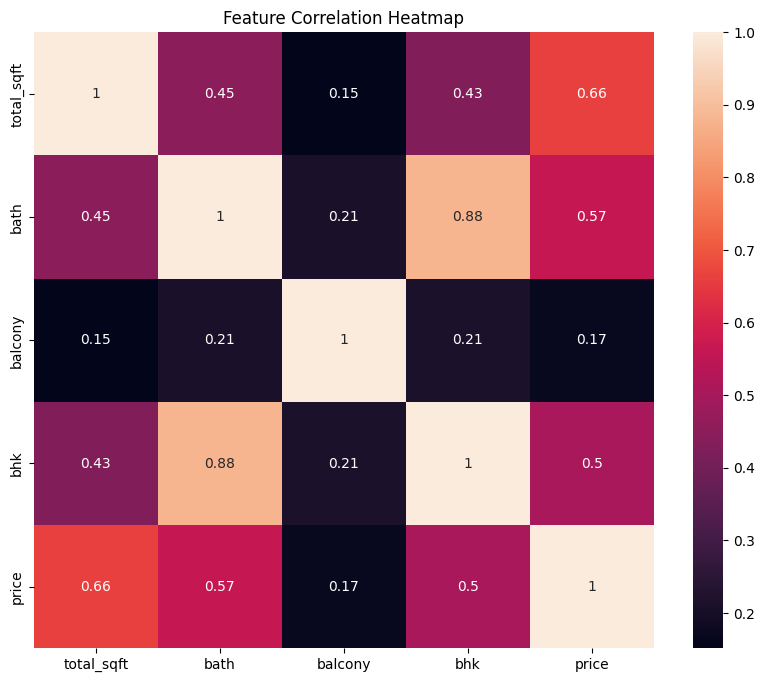

In [50]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df[['total_sqft','bath','balcony','bhk','price']].corr(),
    annot=True
)
plt.title('Feature Correlation Heatmap')
plt.show()

__Property size (total square footage) is the strongest driver of price, followed by number of bathrooms and BHK, while balcony count has minimal impact on pricing__

__Bathrooms and BHK are highly correlated, meaning they capture similar information and are not independent drivers of price.__

* __Bengaluru housing prices are heavily right-skewed, with most properties concentrated in the mid-range segment.__ 
* __Property size is the strongest measurable driver of price, but location creates major pricing variation among similarly sized homes.__
* __Certain localities offer significantly better value per square foot, making them strong options for affordability-focused buyers.__
* __BHK count influences price, but is not the sole determinant.__